# Scenario

A worked example of the `quicksat` scenario, with a TLE orbit and a run of three orbits. A list of activities repeats over the run.

The notebook loads `data/scenario.yaml` and runs it. It then shows the activity table, a Gantt chart and two ground track maps. A list of activities that does not work first shows up here.

In [1]:
# Change log. LAST_CHANGE and CHANGE_NOTE are typed in by hand: update them whenever
# the inputs move -- an activity added, a duration changed, a new TLE -- so that the
# figures below can be read against what produced them. The run time is recorded
# automatically, and says how stale the outputs stored in this notebook are relative
# to that last change.
from datetime import datetime

LAST_CHANGE = "2026-10-03"
CHANGE_NOTE = "Three orbits of a 510 km sun-synchronous orbit, five activities."

print(f"last change  {LAST_CHANGE}")
print(f"             {CHANGE_NOTE}")
print(f"last run     {datetime.now().astimezone():%Y-%m-%d %H:%M %Z}")

last change  2026-10-03
             Three orbits of a 510 km sun-synchronous orbit, five activities.
last run     2026-10-03 20:48 CEST


In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from astropy import units as u

# Make the in-development quicksat package importable without installing it: walk up
# from the current directory to the repo root (the folder that holds the quicksat
# package) and switch to it. Works whether the notebook runs from sample/, the repo
# root, or the docs build.
here = Path.cwd()
repo_root = next(
    (p for p in (here, *here.parents) if (p / "quicksat" / "__init__.py").exists()),
    None,
)
if repo_root is None:
    raise RuntimeError("could not locate the quicksat repo root")
os.chdir(repo_root)

from quicksat.scenario.config import Scenario
from quicksat.scenario.plots import gantt_chart, ground_track_map, scenario_colours
from quicksat.scenario.run import run_scenario
from quicksat.utils.intervals import duration
from quicksat.utils.plot_helpers import STYLE

plt.style.use(STYLE)

## Loading and running

The scenario file names a TLE file, the start time, the duration and the time step. It also sets the axes of the two attitudes and lists the activities.

`run_scenario` evaluates the orbit on the time grid and finds the eclipse entries and exits. Then it repeats the list of activities until the duration ends.

The beta angle is the angle between the sun and the orbit plane. It hardly changes over a run of a few hours.

In [3]:
DATA = Path("sample") / "scenario" / "data"
scenario = Scenario.from_yaml_file(DATA / "scenario.yaml")

run = run_scenario(scenario)

eclipse_fraction = (duration(run.eclipses) / duration(run.interval)).to_value(u.one)

print(f"TLE epoch   {run.tle.epoch.utc.isot} UTC")
print(f"run start   {run.times[0].utc.isot} UTC")
print(f"run end     {run.times[-1].utc.isot} UTC")
print(f"time step   {scenario.step:.0f}")
print(f"beta        {run.beta.min():.2f} to {run.beta.max():.2f}")
print(f"eclipses    {len(run.eclipses)}, {eclipse_fraction:.1%} of the run")

TLE epoch   2026-10-01T00:00:00.000 UTC
run start   2026-10-01T00:00:00.000 UTC
run end     2026-10-01T04:44:33.446 UTC
time step   10 s
beta        -19.33 deg to -19.29 deg
eclipses    3, 36.9% of the run


## The activity table

The list in the file is written once, and the run repeats it until the duration ends. The table has one row for every occurrence of an activity. This is the first check of the activities.

Each activity starts where the one before it ends. A duration trigger ends it after that time. An event trigger ends it at the next such event after its start.

The status is `ok`, or it names a problem. `outside constraint` means the activity spends some time outside the illumination it expects, and the `outside [s]` column gives that time.

`cut at end` means the activity would have run past the end of the run, and it is cut there. That is the normal end of the last activity. It includes an activity whose event happens in the run, but not again before the end. `event never came` means the event never happens in the run at all, such as an eclipse entry in a season with no eclipses. The activity then runs to the end.

In [4]:
print(run.activity_summary)
run.activity_table.style.hide(axis="index").format(
    {"duration [min]": "{:.2f}", "outside [s]": "{:.1f}"}, na_rep=""
)

Occurrences: 13 in 3 repeats. Outside constraint: 0. Event never came: 0. Cut at end: 1.


repeat,activity,start [UTC],end [UTC],duration [min],trigger,attitude,mode,constraint,outside [s],status
1,1,2026-10-01T00:00:00.000,2026-10-01T00:28:17.935,28.30,eclipse entry,sun pointing,idle,sunlit,0.0,ok
1,2,2026-10-01T00:28:17.935,2026-10-01T01:03:18.042,35.00,eclipse exit,nadir,idle,eclipse,0.0,ok
1,3,2026-10-01T01:03:18.042,2026-10-01T01:38:18.042,35.00,35 min,sun pointing,idle,sunlit,0.0,ok
1,4,2026-10-01T01:38:18.042,2026-10-01T01:48:18.042,10.00,10 min,nadir,imaging,sunlit,0.0,ok
1,5,2026-10-01T01:48:18.042,2026-10-01T01:58:18.042,10.00,10 min,nadir,downlink,,,ok
2,1,2026-10-01T01:58:18.042,2026-10-01T02:03:08.653,4.84,eclipse entry,sun pointing,idle,sunlit,0.0,ok
2,2,2026-10-01T02:03:08.653,2026-10-01T02:38:08.805,35.00,eclipse exit,nadir,idle,eclipse,0.0,ok
2,3,2026-10-01T02:38:08.805,2026-10-01T03:13:08.805,35.00,35 min,sun pointing,idle,sunlit,0.0,ok
2,4,2026-10-01T03:13:08.805,2026-10-01T03:23:08.805,10.00,10 min,nadir,imaging,sunlit,0.0,ok
2,5,2026-10-01T03:23:08.805,2026-10-01T03:33:08.805,10.00,10 min,nadir,downlink,,,ok


## Colours

Each value gets one colour, and keeps it in the Gantt chart and in both maps. The values take the colours in a fixed order: the illumination first, then the attitudes, then the modes.

Each colour differs clearly from the one before it, including for readers with colour blindness. A ninth value would be grey.

In [5]:
colours = scenario_colours(scenario)
for value, colour in colours.items():
    print(f"{value:<14}{colour}")

sunlit        #2a78d6
eclipse       #eb6834
nadir         #1baf7a
sun pointing  #eda100
idle          #e87ba4
imaging       #008300
downlink      #4a3aa7


## The Gantt chart

Three rows show the illumination, the attitude and the mode against the time since the start of the run. Each bar carries its value when it is wide enough.

A red box marks an occurrence that spends time outside its constraint. The sample has none, because every constraint holds.

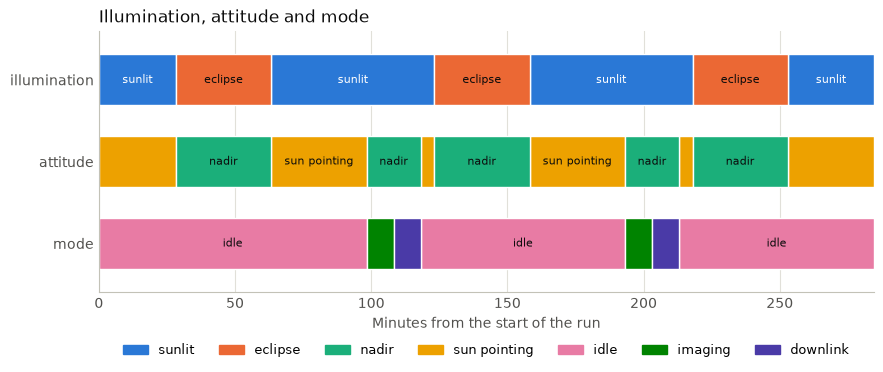

In [6]:
gantt_chart(run, colours)
plt.show()

## The ground tracks

Two maps show the ground track over the coastlines, one coloured by mode and one by attitude. The track is the geodetic latitude and the east longitude below the satellite at each grid step.

The track is broken where the longitude wraps at ±180°. The circle marks the start of the run, and the square marks its end.

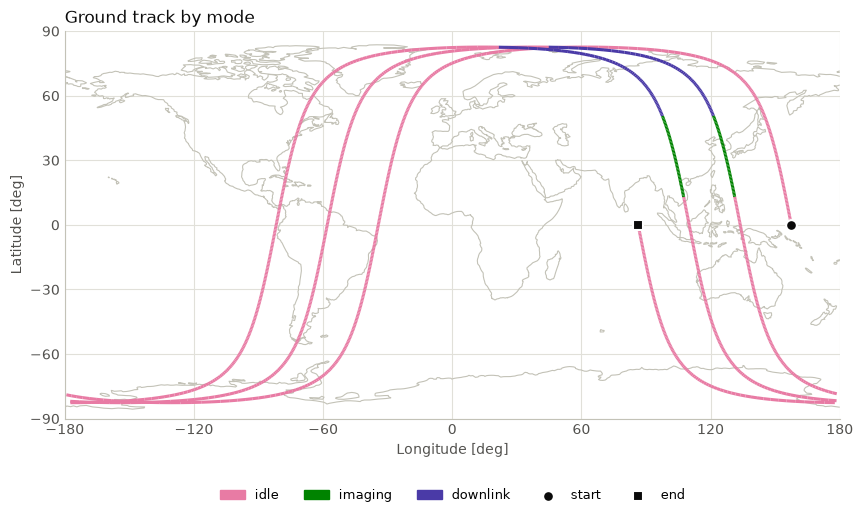

In [7]:
ground_track_map(run, run.mode, "Ground track by mode", colours)
plt.show()

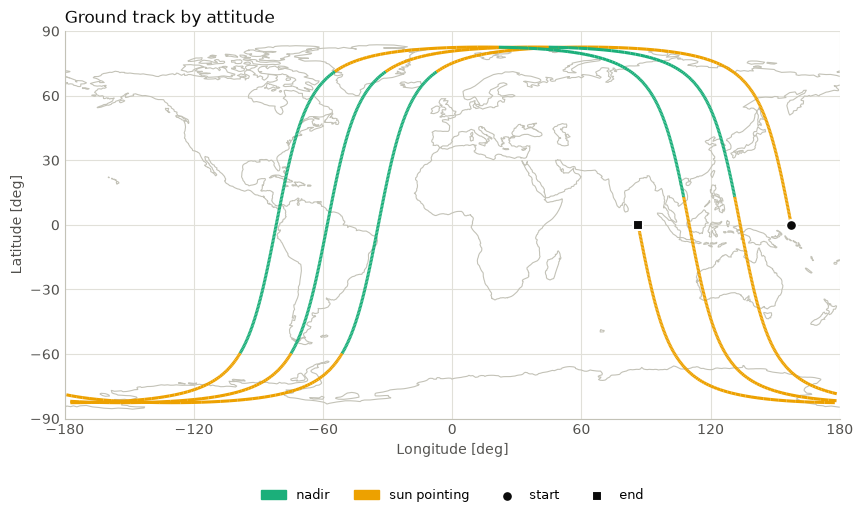

In [8]:
ground_track_map(run, run.attitude, "Ground track by attitude", colours)
plt.show()

## Changing the scenario

Edit `sample/scenario/data/scenario.yaml` and run the notebook again from the top. The notebook never writes that file.

For example, change the sun pointing after the eclipse from `35 min` to `55 min`. The sunlit part of the orbit lasts about 60 minutes, so the imaging after it runs about 5 minutes into the next eclipse. The table then reports it as outside its constraint, and the Gantt chart marks it with a red box. The list then starts again inside that eclipse. Its first activity waits for the next eclipse entry, an orbit later, and fails its `sunlit` constraint too.